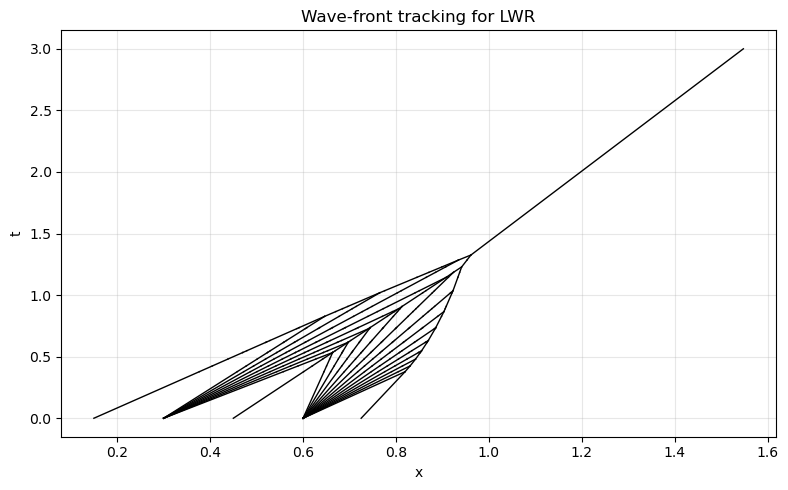

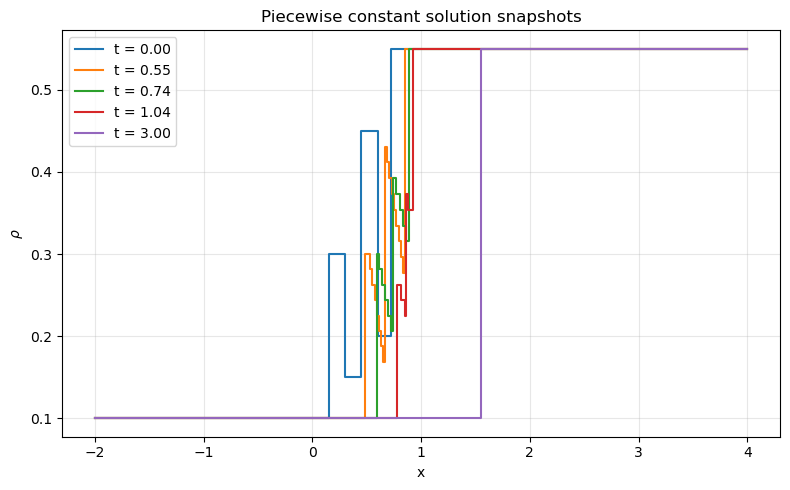

In [21]:
from dataclasses import dataclass
from copy import deepcopy
import math
import numpy as np
import matplotlib.pyplot as plt


@dataclass
class Front:
    """A single discontinuity front."""
    x: float   # position
    ul: float  # left state
    ur: float  # right state
    s: float   # propagation speed


class LWRFrontTracking:
    """
    Front tracking for the LWR model
        rho_t + (rho(1-rho))_x = 0

    Piecewise constant initial data is represented by finitely many fronts.
    Shocks are represented by one front.
    Rarefactions are approximated by a fan of small fronts.
    """

    def __init__(self, boundaries, states, rare_delta=0.02, tol=1e-12):
        """
        Parameters
        ----------
        boundaries : list[float]
            Discontinuity locations [x1, x2, ..., xm].
        states : list[float]
            Piecewise constant states [u0, u1, ..., um],
            where u(x)=u_k on [x_k, x_{k+1}).
            So len(states) = len(boundaries) + 1.
        rare_delta : float
            Rarefaction resolution. Smaller = finer front-tracking approximation.
        tol : float
            Numerical tolerance.
        """
        if len(states) != len(boundaries) + 1:
            raise ValueError("Need len(states) = len(boundaries) + 1.")

        self.rare_delta = float(rare_delta)
        self.tol = float(tol)
        self.left_state = float(states[0])
        self.right_state = float(states[-1])

        self.fronts = []
        for x0, ul, ur in zip(boundaries, states[:-1], states[1:]):
            self.fronts.extend(self.riemann_fronts(ul, ur, x0))

        self.fronts = self._sort_fronts(self.fronts)

    @staticmethod
    def flux(rho):
        return rho * (1.0 - rho)

    @staticmethod
    def dflux(rho):
        return 1.0 - 2.0 * rho

    def speed(self, ul, ur):
        """Rankine-Hugoniot speed."""
        if abs(ur - ul) <= self.tol:
            return self.dflux(0.5 * (ul + ur))
        return (self.flux(ur) - self.flux(ul)) / (ur - ul)

    def riemann_fronts(self, ul, ur, x0):
        """
        Exact Riemann solver in front-tracking form.

        For concave flux f(rho)=rho(1-rho):
        - ul < ur  -> shock
        - ul > ur  -> rarefaction fan (approximated by many small fronts)
        """
        if abs(ur - ul) <= self.tol:
            return []

        # Shock
        if ul < ur:
            return [Front(x=float(x0), ul=float(ul), ur=float(ur), s=self.speed(ul, ur))]

        # Rarefaction fan approximation
        n = max(1, int(math.ceil(abs(ul - ur) / self.rare_delta)))
        states = np.linspace(ul, ur, n + 1)

        fronts = []
        for a, b in zip(states[:-1], states[1:]):
            if abs(b - a) <= self.tol:
                continue
            fronts.append(Front(x=float(x0), ul=float(a), ur=float(b), s=self.speed(a, b)))
        return fronts

    def _sort_fronts(self, fronts):
        # sort by position; if same x, sort by speed so rarefaction fans stay ordered
        return sorted(fronts, key=lambda fr: (fr.x, fr.s))

    def _advance(self, dt):
        for fr in self.fronts:
            fr.x += fr.s * dt

    def _next_event_time(self):
        """
        Return the next collision time among adjacent fronts.
        If no collision exists, return +inf.
        """
        if len(self.fronts) < 2:
            return math.inf

        dt_min = math.inf
        for a, b in zip(self.fronts[:-1], self.fronts[1:]):
            gap = b.x - a.x
            ds = a.s - b.s
            if ds > self.tol:
                dt = gap / ds
                if dt < dt_min:
                    dt_min = dt
        return dt_min

    def _resolve_collisions_at_current_time(self):
        """
        After advancing to the next interaction time, some adjacent fronts
        may now share the same position. Replace each such cluster by the
        Riemann solver between the outer states.
        """
        if not self.fronts:
            return

        new_fronts = []
        i = 0
        n = len(self.fronts)

        while i < n:
            j = i
            while j + 1 < n and abs(self.fronts[j + 1].x - self.fronts[i].x) <= self.tol:
                j += 1

            if j == i:
                new_fronts.append(self.fronts[i])
            else:
                x0 = self.fronts[i].x
                ul = self.fronts[i].ul
                ur = self.fronts[j].ur
                new_fronts.extend(self.riemann_fronts(ul, ur, x0))

            i = j + 1

        self.fronts = self._sort_fronts(new_fronts)

    def simulate(self, T):
        """
        Simulate up to time T.

        Returns
        -------
        segments : list of tuples
            Each tuple is (t0, x0, t1, x1), a straight-line trajectory segment
            for one front during one event interval.
        history : list of tuples
            Each tuple is (t, deepcopy(fronts)) after each event.
        """
        T = float(T)
        t = 0.0
        segments = []
        history = [(t, deepcopy(self.fronts))]

        while t < T and self.fronts:
            dt = self._next_event_time()

            # No more collisions, just advect to final time
            if not math.isfinite(dt) or t + dt > T:
                dt = T - t
                if dt <= self.tol:
                    break

                for fr in self.fronts:
                    segments.append((t, fr.x, t + dt, fr.x + fr.s * dt))
                self._advance(dt)
                t = T
                history.append((t, deepcopy(self.fronts)))
                break

            # If the next event is essentially immediate, resolve it
            if dt <= self.tol:
                self._resolve_collisions_at_current_time()
                history.append((t, deepcopy(self.fronts)))
                continue

            # Move all fronts until the next interaction
            for fr in self.fronts:
                segments.append((t, fr.x, t + dt, fr.x + fr.s * dt))

            self._advance(dt)
            t += dt
            self._resolve_collisions_at_current_time()
            history.append((t, deepcopy(self.fronts)))

        return segments, history

    def profile(self, xmin, xmax, fronts=None, left_state=None):
        """
        Reconstruct a piecewise constant profile for plotting.
        """
        if fronts is None:
            fronts = self.fronts
        if left_state is None:
            left_state = self.left_state

        xs = [xmin]
        us = [left_state]

        state = left_state
        for fr in fronts:
            xs.extend([fr.x, fr.x])
            us.extend([state, fr.ur])
            state = fr.ur

        xs.append(xmax)
        us.append(state)
        return np.array(xs), np.array(us)


if __name__ == "__main__":
    # Example initial data:
    # rho(x,0) = 0.1 for x < 0
    #           = 0.8 for 0 <= x < 1
    #           = 0.2 for x >= 1
    #
    # This produces one shock and one rarefaction fan.
    boundaries = [0.15, 0.3, 0.45, 0.6, 0.725]
    states = [0.1, 0.3, 0.15, 0.45, 0.2, 0.55]

    solver = LWRFrontTracking(boundaries, states, rare_delta=0.02)
    segments, history = solver.simulate(T=3.0)

    # Space-time diagram of fronts
    fig, ax = plt.subplots(figsize=(8, 5))
    for t0, x0, t1, x1 in segments:
        ax.plot([x0, x1], [t0, t1], "k-", lw=1)

    ax.set_xlabel("x")
    ax.set_ylabel("t")
    ax.set_title("Wave-front tracking for LWR")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Snapshot profiles at event times
    fig, ax = plt.subplots(figsize=(8, 5))
    xmin, xmax = -2.0, 4.0

    # Plot a few event-time snapshots
    pick = np.linspace(0, len(history) - 1, min(5, len(history)), dtype=int)
    for idx in pick:
        t, fronts = history[idx]
        xs, us = solver.profile(xmin, xmax, fronts=fronts)
        ax.plot(xs, us, label=f"t = {t:.2f}")

    ax.set_xlabel("x")
    ax.set_ylabel(r"$\rho$")
    ax.set_title("Piecewise constant solution snapshots")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()